In [338]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt

results_df = pd.read_csv('../../Our Datasets/classifier_results_logreg.csv')

possible_match_ids = [1886347, 1899585]

match_id = possible_match_ids[0]

results_df = results_df[results_df['match_id'] == match_id]

results_df.drop(columns=['match_id', 'row_index', 'Unique ID', 'event_index', 'source_file', 'event_row_index', 'rec_team_id', 'true_value'], inplace=True)

results_df

,predicted_class,predicted_probability,frame_start,frame_end,rec_player_id,prev_player_id,prev_player_name,rec_team_short,dist_to_attacking_goal,team_out_of_possession_phase_type,player_targeted_dangerous,is_drawing,is_middle_third
0,0,0.342483,387.0,430.0,51009.0,23418.0,F. Gallegos,Newcastle,99.824911,high_block,0.0,1,0
1,1,0.626395,1492.0,1492.0,966120.0,966120.0,B. Gibson,Newcastle,15.191136,chaotic/disruption,0.0,1,0
2,0,0.490103,3799.0,3799.0,795505.0,965685.0,L. Gillion,Newcastle,53.789297,chaotic/disruption,1.0,1,1
3,0,0.470771,3854.0,3866.0,50951.0,50951.0,J. Brimmer,Auckland FC,63.818283,chaotic/disruption,1.0,1,1
4,1,0.584672,4452.0,4452.0,735573.0,735573.0,T. Aquilina,Newcastle,80.062537,medium_block,1.0,1,0
5,0,0.478093,7480.0,7480.0,735574.0,735574.0,K. Grozos,Newcastle,59.860600,chaotic/disruption,0.0,1,1
6,1,0.604222,8011.0,8011.0,795505.0,33697.0,N. Pijnaker,Newcastle,26.908750,chaotic/disruption,0.0,1,0
7,1,0.658982,9289.0,9301.0,14736.0,51649.0,A. Šušnjar,Auckland FC,38.797290,low_block,0.0,1,1
8,0,0.372183,9686.0,9696.0,735578.0,735578.0,M. Natta,Newcastle,82.309782,high_block,0.0,1,0
9,0,0.356012,10163.0,10170.0,735574.0,735574.0,K. Grozos,Newcastle,91.332827,high_block,0.0,1,0


In [ ]:
def time_to_seconds(time_str):
    if time_str is None:
        return 90 * 60  # 120 minutes = 7200 seconds
    h, m, s = map(int, time_str.split(':'))
    return h * 3600 + m * 60 + s

file_path = f"../../data/matches/{match_id}/{match_id}_match.json"

with open(file_path, "r") as f:
    raw_match_data = json.load(f)

# The output has nested json elements. We process them
raw_match_df = pd.json_normalize(raw_match_data, max_level=2)
raw_match_df["home_team_side"] = raw_match_df["home_team_side"].astype(str)

players_df = pd.json_normalize(
    raw_match_df.to_dict("records"),
    record_path="players",
    meta=[
        "home_team_score",
        "away_team_score",
        "date_time",
        "home_team_side",
        "home_team.name",
        "home_team.id",
        "away_team.name",
        "away_team.id",
    ],  # data we keep
)


# Take only players who played and create their total time
players_df = players_df[
    ~((players_df.start_time.isna()) & (players_df.end_time.isna()))
]

# Create a flag for GK
players_df["is_gk"] = players_df["player_role.acronym"] == "GK"

# Add a flag if the given player is home or away
players_df["match_name"] = (
    players_df["home_team.name"] + " vs " + players_df["away_team.name"]
)


# Add a flag if the given player is home or away
players_df["home_away_player"] = np.where(
    players_df.team_id == players_df["home_team.id"], "Home", "Away"
)

# Create flag from player
players_df["team_name"] = np.where(
    players_df.team_id == players_df["home_team.id"],
    players_df["home_team.name"],
    players_df["away_team.name"],
)

# Figure out sides
players_df[["home_team_side_1st_half", "home_team_side_2nd_half"]] = (
    players_df["home_team_side"]
    .astype(str)
    .str.strip("[]")
    .str.replace("'", "")
    .str.split(", ", expand=True)
)
# Clean up sides
players_df["direction_player_1st_half"] = np.where(
    players_df.home_away_player == "Home",
    players_df.home_team_side_1st_half,
    players_df.home_team_side_2nd_half,
)
players_df["direction_player_2nd_half"] = np.where(
    players_df.home_away_player == "Home",
    players_df.home_team_side_2nd_half,
    players_df.home_team_side_1st_half,
)


# Clean up and keep the columns that we want to keep about

columns_to_keep = [
    "id",
    "short_name",
    "team_name",
    "player_role.name",
]
players_df = players_df[columns_to_keep]

,id,short_name,team_name,player_role.name
0,38673,G. May,Auckland FC,Center Forward
1,51713,C. Elliott,Auckland FC,Right Back
2,50951,J. Brimmer,Auckland FC,Center Forward
3,50978,C. Timmins,Newcastle United Jets FC,Left Defensive Midfield
4,133498,F. De Vries,Auckland FC,Left Back
5,33697,N. Pijnaker,Auckland FC,Left Center Back
6,51667,D. Hall,Auckland FC,Right Center Back
7,14736,L. Verstraete,Auckland FC,Defensive Midfield
11,735573,T. Aquilina,Newcastle United Jets FC,Left Winger
12,51009,R. Scott,Newcastle United Jets FC,Goalkeeper


In [340]:
summary_df = pd.merge(results_df, players_df, left_on='rec_player_id', right_on='id', how='right')

summary_df = summary_df.dropna(subset=['predicted_class'])

summary_df

,predicted_class,predicted_probability,frame_start,frame_end,rec_player_id,prev_player_id,prev_player_name,rec_team_short,dist_to_attacking_goal,team_out_of_possession_phase_type,player_targeted_dangerous,is_drawing,is_middle_third,id,short_name,team_name,player_role.name
1,0.0,0.342496,10754.0,10754.0,51713.0,735573.0,T. Aquilina,Auckland FC,99.016933,high_block,0.0,1.0,0.0,51713,C. Elliott,Auckland FC,Right Back
2,1.0,0.589266,11857.0,11887.0,51713.0,51713.0,C. Elliott,Auckland FC,43.108914,medium_block,0.0,1.0,1.0,51713,C. Elliott,Auckland FC,Right Back
3,1.0,0.671710,28619.0,28647.0,51713.0,51713.0,C. Elliott,Auckland FC,29.112530,medium_block,1.0,1.0,0.0,51713,C. Elliott,Auckland FC,Right Back
4,1.0,0.532050,57138.0,57138.0,51713.0,51713.0,C. Elliott,Auckland FC,55.966937,chaotic/disruption,0.0,0.0,1.0,51713,C. Elliott,Auckland FC,Right Back
5,0.0,0.241640,1667.0,1715.0,51713.0,51713.0,C. Elliott,Auckland FC,88.828844,high_block,0.0,1.0,0.0,51713,C. Elliott,Auckland FC,Right Back
6,0.0,0.470771,3854.0,3866.0,50951.0,50951.0,J. Brimmer,Auckland FC,63.818283,chaotic/disruption,1.0,1.0,1.0,50951,J. Brimmer,Auckland FC,Center Forward
7,0.0,0.331796,8800.0,8808.0,50978.0,50978.0,C. Timmins,Newcastle,64.933755,chaotic/disruption,0.0,1.0,1.0,50978,C. Timmins,Newcastle United Jets FC,Left Defensive Midfield
8,0.0,0.357635,29473.0,29477.0,133498.0,966120.0,B. Gibson,Auckland FC,52.998107,high_block,0.0,1.0,1.0,133498,F. De Vries,Auckland FC,Left Back
9,1.0,0.549429,30012.0,30012.0,133498.0,51009.0,R. Scott,Auckland FC,60.921018,medium_block,0.0,1.0,1.0,133498,F. De Vries,Auckland FC,Left Back
10,1.0,0.728884,47322.0,47322.0,133498.0,133498.0,F. De Vries,Auckland FC,61.781680,transition/quick_break,1.0,1.0,1.0,133498,F. De Vries,Auckland FC,Left Back


In [342]:
player_df_recoveries = (
    summary_df
    .groupby(['short_name', 'rec_team_short'])
    .agg(
        total_recoveries = ('predicted_class', 'count'),
        dangerous_recoveries_pred = ('predicted_class', 'sum'),
        avg_pred_prob = ('predicted_probability', 'mean')
    )
    .reset_index()
)

player_df_recoveries.sort_values(by='dangerous_recoveries_pred', ascending=False, inplace=True)

player_df_recoveries

,short_name,rec_team_short,total_recoveries,dangerous_recoveries_pred,avg_pred_prob
2,C. Elliott,Auckland FC,5,3.0,0.475432
15,L. Verstraete,Auckland FC,4,2.0,0.530239
18,P. Cancar,Newcastle,2,2.0,0.598183
11,K. Grozos,Newcastle,6,2.0,0.468437
7,F. De Vries,Auckland FC,3,2.0,0.545316
19,R. Scott,Newcastle,3,1.0,0.425074
17,N. Pijnaker,Auckland FC,1,1.0,0.597507
20,T. Aquilina,Newcastle,4,1.0,0.462037
1,B. Gibson,Newcastle,2,1.0,0.540792
12,L. Bayliss,Newcastle,2,1.0,0.453972


In [343]:
team_df_recoveries = (
    summary_df
    .groupby(['rec_team_short'])
    .agg(
        total_recoveries = ('predicted_class', 'count'),
        dangerous_recoveries_pred = ('predicted_class', lambda s: (s == 1).sum()),
        avg_pred_prob = ('predicted_probability', 'mean')
    )
    .reset_index()
)

team_df_recoveries.sort_values(by='dangerous_recoveries_pred', ascending=False, inplace=True)

team_df_recoveries

,rec_team_short,total_recoveries,dangerous_recoveries_pred,avg_pred_prob
0,Auckland FC,23,10,0.496266
1,Newcastle,32,10,0.462740


In [344]:
FPS = 10  # frames per second

def danger_cumulative_binned(df, team_name, fps=FPS):

    dft = df[df['rec_team_short'] == team_name].copy()

    # time axis from frame_start
    dft['seconds'] = dft['frame_start'] / fps
    dft['minutes'] = dft['seconds'] / 60

    # 15-min bins
    bins = ["0–15","15–30","30–45","45–60","60–75","75–90","90–100"]

    dft["minute_bin"] = pd.cut(
        dft["minutes"],
        bins=range(0, 115, 15),   # 0..105 by 15
        right=False,
        labels=bins
    )

    # count predicted_class==1 in each bin
    binned = (
        dft.groupby("minute_bin")
        .agg(danger_count=("predicted_class", lambda s: (s == 1).sum()))
        .reindex(bins, fill_value=0)  # ensure missing bins = 0
        .reset_index()
    )

    # cumulative
    binned["danger_cum"] = binned["danger_count"].cumsum()

    return binned

In [345]:
def plot_two_teams_count(b1, b2, team1, team2):

    plt.figure(figsize=(12,5))

    # area + line — TEAM 1
    plt.fill_between(
        b1["minute_bin"].astype(str),
        b1["danger_count"],
        alpha=0.40,
        step="mid",
        color="tab:blue",
        label=f"{team1} (area)"
    )

    plt.plot(
        b1["minute_bin"].astype(str),
        b1["danger_count"],
        drawstyle="steps-mid",
        color="tab:blue",
        label=f"{team1}"
    )


    # area + line — TEAM 2
    plt.fill_between(
        b2["minute_bin"].astype(str),
        b2["danger_count"],
        alpha=0.40,
        step="mid",
        color="tab:red",
        label=f"{team2} (area)"
    )

    plt.plot(
        b2["minute_bin"].astype(str),
        b2["danger_count"],
        drawstyle="steps-mid",
        color="tab:red",
        label=f"{team2}"
    )

    # tidy formatting
    ax = plt.gca()
    ax.margins(x=0)

    plt.ylabel("Dangerous Recoveries")
    plt.xlabel("Match Time (15-min bins)")
    plt.title("Dangerous Recoveries — Both Teams")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [346]:
team1 = "Auckland FC"
team2 = "Newcastle"   # <-- change this to the real name

b1 = danger_cumulative_binned(summary_df, team1)
b2 = danger_cumulative_binned(summary_df, team2)

C:\Users\navee\AppData\Local\Temp\ipykernel_49016\2589399450.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dft.groupby("minute_bin")
C:\Users\navee\AppData\Local\Temp\ipykernel_49016\2589399450.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dft.groupby("minute_bin")


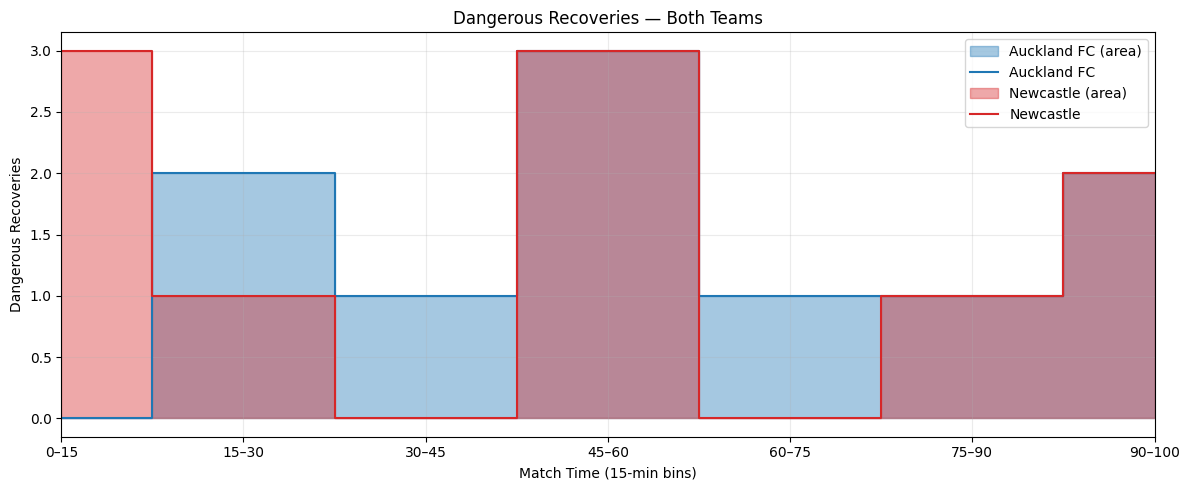

In [347]:
plot_two_teams_count(b1, b2, team1, team2)

In [348]:
b1

,minute_bin,danger_count,danger_cum
0,0–15,0,0
1,15–30,2,2
2,30–45,1,3
3,45–60,3,6
4,60–75,1,7
5,75–90,1,8
6,90–100,2,10
